# Navie Bayes

In [2]:
# import libraries
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# import libraries
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# load the dataset
df=pd.read_csv("C:\\Users\\guntu\\OneDrive\\Desktop\\NB\\NB\\Naive-Bayes-Classification-Data.csv")
df

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1
...,...,...,...
990,45,87,0
991,40,83,0
992,40,83,0
993,40,60,1


In [5]:
df.shape

(995, 3)

In [6]:
df.head()

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1


In [7]:
# data preproccessing
df.isnull().sum()

glucose          0
bloodpressure    0
diabetes         0
dtype: int64

In [8]:
df.duplicated().any()

np.True_

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   glucose        995 non-null    int64
 1   bloodpressure  995 non-null    int64
 2   diabetes       995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB


In [10]:
df.describe()

,glucose,bloodpressure,diabetes
count,995.000000,995.000000,995.000000
mean,44.306533,79.184925,0.500503
std,6.707567,9.340204,0.500251
min,20.000000,50.000000,0.000000
25%,40.000000,72.000000,0.000000
50%,45.000000,80.000000,1.000000
75%,50.000000,87.000000,1.000000
max,70.000000,100.000000,1.000000


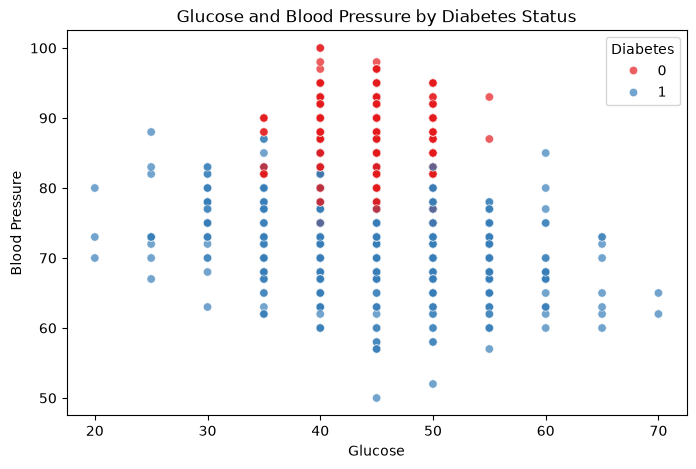

In [11]:
# the plot shown
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="glucose",
    y="bloodpressure",
    hue="diabetes",
    palette="Set1",
    alpha=0.7
)

plt.title("Glucose and Blood Pressure by Diabetes Status")
plt.xlabel("Glucose")
plt.ylabel("Blood Pressure")
plt.legend(title="Diabetes")
plt.show()

In [12]:
# check target varibles
# X and y
X = df[["glucose", "bloodpressure"]]
y = df["diabetes"]


In [14]:
from sklearn.model_selection import train_test_split


In [15]:

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [16]:
# import libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Create model
nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

# Prediction
y_pred = nb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.9095477386934674
Accuracy percentage: 90.95477386934674


In [18]:
# also check all metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss
)

y_prob = nb_model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9095477386934674
Precision: 0.91
Recall: 0.91
F1 Score: 0.91
Log Loss: 0.20053112711047058

Confusion Matrix:
[[90  9]
 [ 9 91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        99
           1       0.91      0.91      0.91       100

    accuracy                           0.91       199
   macro avg       0.91      0.91      0.91       199
weighted avg       0.91      0.91      0.91       199

